# MILP exact vs Descente de Gradient
Comparaison sur un probleme combinatoire (sac a dos 0/1) : l'optimisation exacte garantit des decisions binaires realisables, la relaxation continue produit une borne mais des solutions physiquement incoherentes.

In [1]:
# =============================================================
# Comparaison : Optimisation exacte (MILP) vs Descente de Gradient
# Probleme support : Sac a dos 0/1 (Knapsack)
# =============================================================
import numpy as np
import pulp
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [2]:
# -------------------- Donnees du probleme --------------------
N_ITEMS  = 12
values   = np.array([78, 35, 89, 36, 94, 75, 74, 79, 80, 16, 61, 22], dtype=float)
weights  = np.array([18, 9, 23, 20, 59, 61, 70, 75, 76, 30, 84, 40], dtype=float)
CAPACITY = 250.0

print(f"Items      : {N_ITEMS}")
print(f"Valeurs    : {values.astype(int)}")
print(f"Poids      : {weights.astype(int)}")
print(f"Capacite   : {CAPACITY}")
print(f"Poids total: {weights.sum()}  ->  taux de remplissage max "
      f"{CAPACITY / weights.sum():.1%}")

Items      : 12
Valeurs    : [78 35 89 36 94 75 74 79 80 16 61 22]
Poids      : [18  9 23 20 59 61 70 75 76 30 84 40]
Capacite   : 250.0
Poids total: 565.0  ->  taux de remplissage max 44.2%


In [3]:
# -------------------- 1) Resolution EXACTE : MILP binaire --------------------
def solve_milp(values, weights, capacity):
    """Maximise sum(v_i x_i) s.c. sum(w_i x_i) <= C, x_i dans {0, 1}."""
    prob = pulp.LpProblem("Knapsack_MILP", pulp.LpMaximize)
    x = [pulp.LpVariable(f"x_{i}", cat="Binary") for i in range(len(values))]

    prob += pulp.lpSum(values[i] * x[i] for i in range(len(values))), "valeur_totale"
    prob += pulp.lpSum(weights[i] * x[i] for i in range(len(values))) <= capacity, "capacite"

    prob.solve(pulp.PULP_CBC_CMD(msg=0))

    sol = np.array([float(v.value()) for v in x])
    return sol, float(pulp.value(prob.objective)), pulp.LpStatus[prob.status]


x_milp, obj_milp, status = solve_milp(values, weights, CAPACITY)

print(f"Statut MILP     : {status}")
print(f"Solution x*     : {x_milp.astype(int)}")
print(f"Valeur optimale : {obj_milp:.2f}")
print(f"Poids utilise   : {weights @ x_milp:.2f} / {CAPACITY}")

Statut MILP     : Optimal
Solution x*     : [1 1 1 0 1 1 0 0 1 0 0 0]
Valeur optimale : 451.00
Poids utilise   : 246.00 / 250.0


Solution relachee x (continue) :
[0.789 0.56  0.887 0.301 0.748 0.521 0.461 0.49  0.496 0.019 0.237 0.033]

Loss initiale : 4911.750
Loss finale   : -408.196
Valeur relachee (-loss) : 408.20
Poids utilise : 250.11 / 250.0

>>> Variables FRACTIONNAIRES (physiquement impossibles) : 12/12


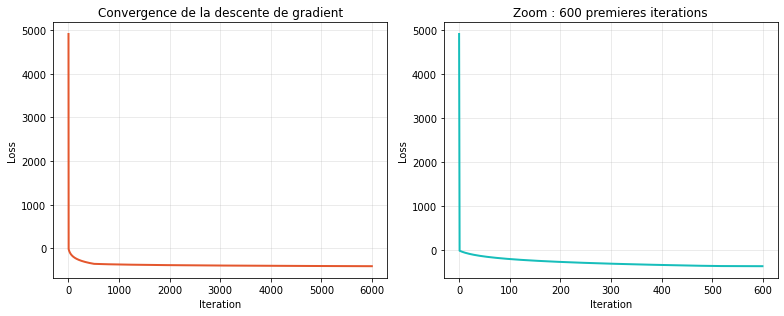

In [4]:
# ---------- 2) Resolution RELACHEE : descente de gradient projetee ----------
# Relaxation : x_i dans [0, 1] (continu) au lieu de {0, 1}.
# Loss(x) = -v.x + rho * relu(w.x - C)^2   (penalite quadratique exterieure)

def gradient_descent(values, weights, capacity, lr0=1e-4, rho=5.0,
                     n_iter=6000, decay=0.05, x0=None):
    """Descente de gradient projetee sur la relaxation continue [0,1]^n.

    Pas decroissant lr_t = lr0 / (1 + decay * t) : sans amortissement, la
    penalite exterieure fait osciller la loss autour de la contrainte saturee.
    """
    n = len(values)
    x = np.full(n, 0.5) if x0 is None else np.array(x0, dtype=float)
    history = []

    for it in range(n_iter):
        overload = weights @ x - capacity
        violation = max(0.0, overload)

        loss = -(values @ x) + rho * violation ** 2
        history.append(loss)

        grad = -values + 2.0 * rho * violation * weights
        lr = lr0 / (1.0 + decay * it)              # pas decroissant
        x = np.clip(x - lr * grad, 0.0, 1.0)       # projection sur [0,1]

    return x, np.array(history)


x_grad, loss_history = gradient_descent(values, weights, CAPACITY)

print(f"Solution relachee x (continue) :\n{np.round(x_grad, 3)}")
print(f"\nLoss initiale : {loss_history[0]:.3f}")
print(f"Loss finale   : {loss_history[-1]:.3f}")
print(f"Valeur relachee (-loss) : {-loss_history[-1]:.2f}")
print(f"Poids utilise : {weights @ x_grad:.2f} / {CAPACITY}")

n_frac = int(np.sum((x_grad > 1e-3) & (x_grad < 1 - 1e-3)))
print(f"\n>>> Variables FRACTIONNAIRES (physiquement impossibles) : {n_frac}/{len(x_grad)}")

# ---- Courbe de convergence ----
fig, ax = plt.subplots(1, 2)
ax[0].plot(loss_history, color="#E4572E", lw=2)
ax[0].set_title("Convergence de la descente de gradient")
ax[0].set_xlabel("Iteration"); ax[0].set_ylabel("Loss")

ax[1].plot(loss_history[:600], color="#17BEBB", lw=2)
ax[1].set_title("Zoom : 600 premieres iterations")
ax[1].set_xlabel("Iteration"); ax[1].set_ylabel("Loss")
plt.tight_layout(); plt.show()

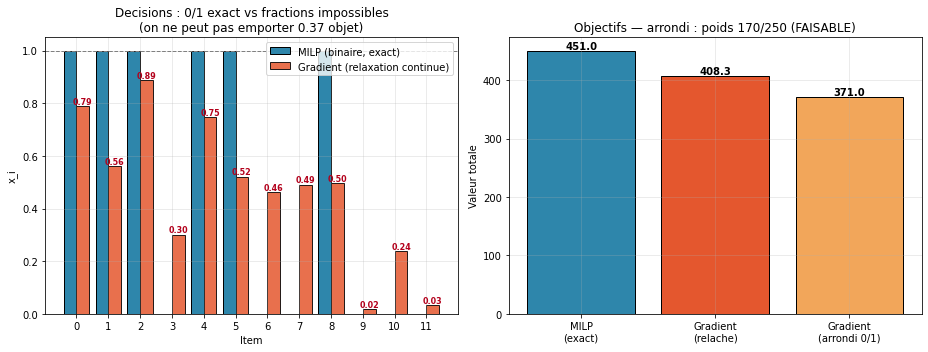

MILP exact            : 451.00 (poids 246)
Gradient relache      : 408.26 -> borne, solution non physique
Gradient arrondi 0/1  : 371.00 (poids 170) -> faisable
Ecart d'optimalite de l'arrondi : 17.74 %


In [5]:
# -------------------- 3) Comparaison MILP vs Gradient --------------------
idx = np.arange(len(values))
width = 0.4

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# --- (a) Decisions item par item ---
ax[0].bar(idx - width/2, x_milp, width, label="MILP (binaire, exact)",
          color="#2E86AB", edgecolor="black")
ax[0].bar(idx + width/2, x_grad, width, label="Gradient (relaxation continue)",
          color="#E4572E", edgecolor="black", alpha=0.85)
ax[0].axhline(1.0, color="grey", ls="--", lw=1)
ax[0].axhline(0.0, color="grey", ls="--", lw=1)

# Marque les valeurs fractionnaires : incoherence physique
for i, xi in enumerate(x_grad):
    if 1e-3 < xi < 1 - 1e-3:
        ax[0].annotate(f"{xi:.2f}", (i + width/2, xi), ha="center",
                       va="bottom", fontsize=8, color="#B3001B", weight="bold")

ax[0].set_xticks(idx); ax[0].set_xlabel("Item"); ax[0].set_ylabel("x_i")
ax[0].set_title("Decisions : 0/1 exact vs fractions impossibles\n"
                "(on ne peut pas emporter 0.37 objet)")
ax[0].legend()

# --- (b) Valeurs objectif et faisabilite ---
val_milp = float(values @ x_milp)
val_grad_relax = float(values @ x_grad)
x_round = (x_grad >= 0.5).astype(float)
val_round = float(values @ x_round)
w_round = float(weights @ x_round)
feasible_round = w_round <= CAPACITY

bars = ax[1].bar(
    ["MILP\n(exact)", "Gradient\n(relache)", "Gradient\n(arrondi 0/1)"],
    [val_milp, val_grad_relax, val_round],
    color=["#2E86AB", "#E4572E", "#F2A65A"], edgecolor="black",
)
for b, v in zip(bars, [val_milp, val_grad_relax, val_round]):
    ax[1].text(b.get_x() + b.get_width()/2, v + 3, f"{v:.1f}",
               ha="center", weight="bold")

ax[1].set_ylabel("Valeur totale")
ax[1].set_title(
    f"Objectifs — arrondi : poids {w_round:.0f}/{CAPACITY:.0f} "
    f"({'FAISABLE' if feasible_round else 'INFAISABLE'})"
)
plt.tight_layout(); plt.show()

print(f"MILP exact            : {val_milp:.2f} (poids {weights @ x_milp:.0f})")
print(f"Gradient relache      : {val_grad_relax:.2f} -> borne, solution non physique")
print(f"Gradient arrondi 0/1  : {val_round:.2f} (poids {w_round:.0f}) "
      f"-> {'faisable' if feasible_round else 'VIOLE LA CAPACITE'}")
print(f"Ecart d'optimalite de l'arrondi : {100 * (val_milp - val_round) / val_milp:.2f} %")